In [1]:
import os
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input


In [2]:
PROJECT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

MODELS_DIR = os.path.join(PROJECT_DIR, "models")

RESNET_MODEL_PATH = os.path.join(MODELS_DIR, "resnet50_best.h5")
EFF_MODEL_PATH    = os.path.join(MODELS_DIR, "efficientnetb0_best.h5")

resnet_model = load_model(RESNET_MODEL_PATH)
eff_model    = load_model(EFF_MODEL_PATH)

print("Models loaded")


Models loaded


In [3]:
def preprocess_resnet(img_path, img_size=224):
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img = image.img_to_array(img).astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    gray = gray.astype(np.float32) / 255.0
    x = np.stack([gray, gray, gray], axis=-1)
    return np.expand_dims(x, axis=0)


In [4]:
def preprocess_effnet(img_path, img_size=224):
    img = image.load_img(img_path, target_size=(img_size, img_size))
    img = image.img_to_array(img).astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(2.0, (8,8))
    gray = clahe.apply(gray)
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    x = np.stack([gray, gray, gray], axis=-1)
    x = eff_preprocess_input(x.astype(np.float32))
    return np.expand_dims(x, axis=0)


In [5]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]  # binary class

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [6]:
def overlay_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224,224))

    heatmap = cv2.resize(heatmap, (224,224))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 1-alpha, heatmap, alpha, 0)

    return img, heatmap, overlay


dataset/test/Stroke/
or
dataset/test/Normal/


In [7]:
img_path = os.path.join(PROJECT_DIR, "dataset", "test", "Stroke", "58 (32).jpg")


ResNet50 Grad-CAM

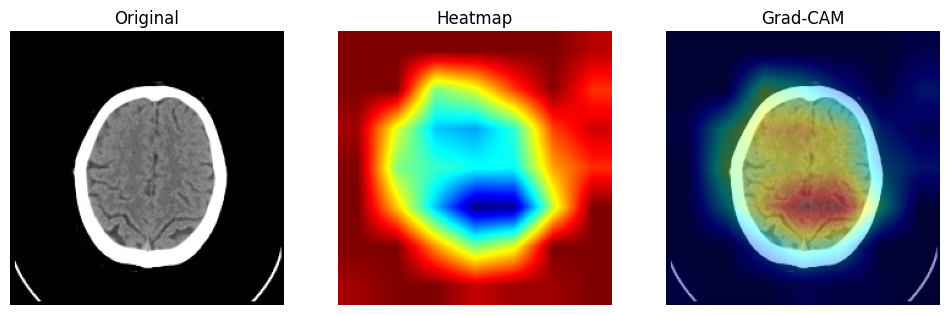

In [8]:
resnet_input = preprocess_resnet(img_path)
resnet_heatmap = make_gradcam_heatmap(
    resnet_input,
    resnet_model,
    last_conv_layer_name="conv5_block3_out"
)

img, heat, overlay = overlay_gradcam(img_path, resnet_heatmap)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,3,2); plt.title("Heatmap"); plt.imshow(heat); plt.axis("off")
plt.subplot(1,3,3); plt.title("Grad-CAM"); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()


EfficientNet-B0 Grad-CAM

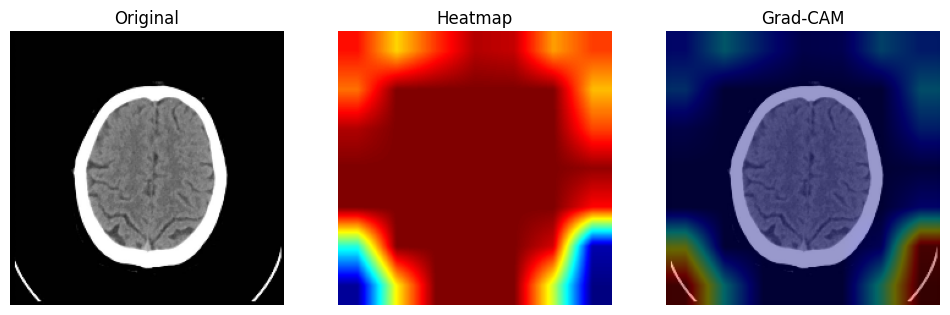

In [9]:
eff_input = preprocess_effnet(img_path)
eff_heatmap = make_gradcam_heatmap(
    eff_input,
    eff_model,
    last_conv_layer_name="top_conv"
)

img, heat, overlay = overlay_gradcam(img_path, eff_heatmap)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.subplot(1,3,2); plt.title("Heatmap"); plt.imshow(heat); plt.axis("off")
plt.subplot(1,3,3); plt.title("Grad-CAM"); plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.show()
